# Conditional Sampling of GP Coefficients

Discovery provides methods to sample GP coefficients conditionally on
hyperparameter values. This allows drawing realizations of stochastic processes
given their amplitude and spectral properties, which is useful for simulations
and diagnostics.

## Overview

In Discovery's GP framework, a Gaussian process is represented by:

- **Basis matrix** $F$ (`ntoas` $\times$ `ngp`)
- **Coefficients** $a$ (latent variables)
- **Prior covariance** $\Phi(\Lambda)$ determined by hyperparameters $\Lambda$

The marginalized likelihood integrates out the coefficients $a$. However, we can
sample from the conditional distribution:

$$p(a \mid y, \Lambda) \propto p(y \mid a)\, p(a \mid \Lambda)$$

This gives us realizations of the GP coefficients that are consistent with both
the data and the hyperparameters.

## The conditional distribution

Given data $y$, noise $N$, basis $F$, and hyperparameters $\Lambda$, the
conditional posterior for the coefficients is Gaussian:

$$a \mid y, \Lambda \sim \mathcal{N}(\mu_a, \Sigma_a)$$

where

$$
\begin{aligned}
\Sigma_a &= \left(\Phi^{-1} + F^{T} N^{-1} F\right)^{-1} \\
\mu_a &= \Sigma_a\, F^{T} N^{-1} y
\end{aligned}
$$

The mean $\mu_a$ is the maximum a posteriori (MAP) estimate of the coefficients,
while $\Sigma_a$ quantifies the uncertainty given the data and hyperparameters.

## Single pulsar

We build a `PulsarLikelihood` for a single pulsar with several GPs: a (variable)
timing model, ECORR, an achromatic red-noise process, and a chromatic
DM-variation process. Each GP contributes a block of columns to the design
matrix and a block of coefficients.

In [1]:
from pathlib import Path

import numpy as np
import jax
import matplotlib.pyplot as plt

import discovery as ds

datapath = Path(ds.__path__[0]) / '../../data'
psr = ds.Pulsar.read_feather(
    str(datapath / 'v1p1_de440_pint_bipm2019-B1855+09.feather'))

signals = [
    psr.residuals,
    ds.makenoise_measurement(psr, psr.noisedict, ecorr=True),
    ds.makegp_timing(psr, svd=True, variable=True),
    ds.makegp_ecorr(psr, psr.noisedict),
    ds.makegp_fourier(psr, ds.powerlaw, 30, name='red_noise'),
    ds.makegp_fourier(psr, ds.powerlaw, 30, name='dmgp',
                      fourierbasis=ds.dmfourierbasis),
]

psrl = ds.PulsarLikelihood(signals)
print(f"{len(psrl.logL.params)} hyperparameters")

4 hyperparameters


### The `conditional` method

`conditional` returns the mean $\mu_a$ and the Cholesky factor of the covariance
$\Sigma_a$ of the conditional coefficient distribution, evaluated at a given set
of hyperparameters. Here we draw the hyperparameters from their priors.

In [2]:
# draw hyperparameters from their priors
params = ds.sample_uniform(psrl.logL.params, ds.prior.priordict_standard)

# mean and Cholesky factor of the conditional coefficient distribution
mu, cf = psrl.conditional(params)
print("mu (first 5 entries):", np.asarray(mu[:5]))

mu (first 5 entries): [-5.15681203e-05 -1.07015005e-05 -1.04284690e-06 -3.46218584e-06
 -1.09972195e-05]


`mu` is a single concatenated vector holding the coefficients of *all* the GPs.
The `N.index` attribute records which slice of that vector belongs to which GP
-- this is the packing you need to split `mu` (or any drawn sample) back into
per-GP pieces.

In [3]:
for name, sl in psrl.N.index.items():
    print(f"{name:42s} -> {sl}")

B1855+09_timingmodel_coefficients(166)     -> slice(0, 166, None)
B1855+09_red_noise_coefficients(60)        -> slice(166, 226, None)
B1855+09_dmgp_coefficients(60)             -> slice(226, 286, None)


### Sampling from the conditional

`sample_conditional` draws a random realization of the coefficients from
$\mathcal{N}(\mu_a, \Sigma_a)$. It takes a JAX PRNG key and returns an updated
key together with a dictionary of per-GP coefficient arrays. Passing the
returned key into the next call gives independent draws.

In [4]:
key = jax.random.key(0)
key, coefficients = psrl.sample_conditional(key, params)

for name, c in coefficients.items():
    print(f"{name:42s} shape {np.asarray(c).shape}")

B1855+09_timingmodel_coefficients(166)     shape (166,)
B1855+09_red_noise_coefficients(60)        shape (60,)
B1855+09_dmgp_coefficients(60)             shape (60,)


The coefficient dictionary is keyed exactly like `N.index`, so the same keys
index both the coefficient blocks and the design-matrix column blocks.

### Total reconstruction

The full design matrix is `psrl.N.F`. Multiplying each GP's column block by its
sampled coefficients and summing gives the model's reconstruction of the
residuals.

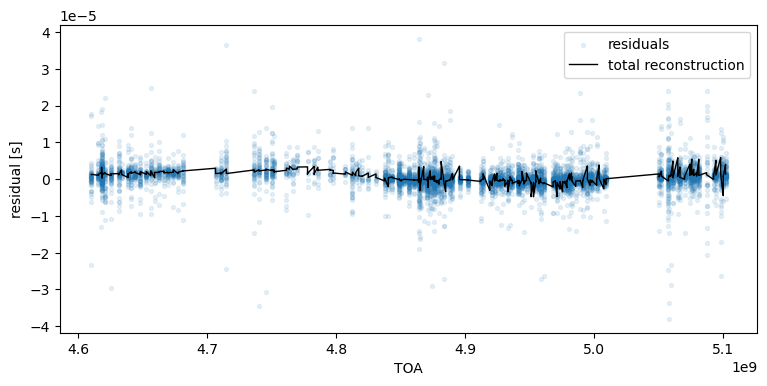

In [5]:
# the full design matrix, and the per-GP column blocks
total_basis = psrl.N.F
separate_bases = {k: total_basis[:, s] for k, s in psrl.N.index.items()}

# total reconstruction = sum over GPs of (basis block) @ (its coefficients)
total = sum(separate_bases[k] @ coefficients[k] for k in coefficients)

plt.figure(figsize=(9, 4))
plt.scatter(psr.toas, psr.residuals, c='C0', alpha=0.1, s=8, label='residuals')
plt.plot(psr.toas, total, c='k', lw=1.0, label='total reconstruction')
plt.xlabel('TOA')
plt.ylabel('residual [s]')
plt.legend()
plt.show()

### Per-process reconstructions

Because each GP has its own basis block, we can also reconstruct each process
separately. Drawing many conditional realizations at the *same* hyperparameters
shows the spread of each process given the data.

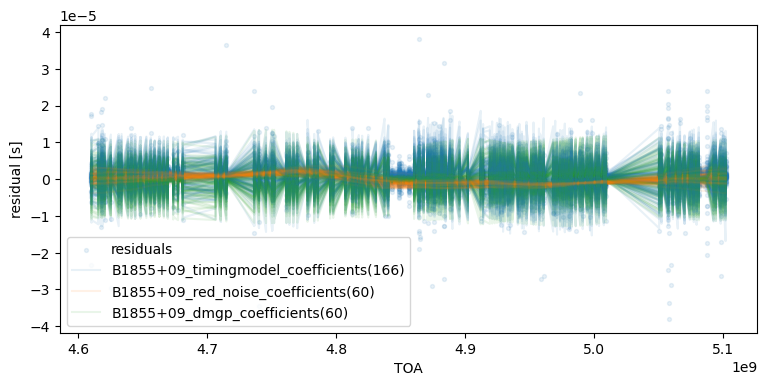

In [6]:
plt.figure(figsize=(9, 4))
plt.scatter(psr.toas, psr.residuals, c='C0', alpha=0.1, s=8, label='residuals')

# 100 conditional realizations at the SAME hyperparameters
for ii in range(100):
    key, coefficients = psrl.sample_conditional(key, params)
    for jj, k in enumerate(separate_bases):
        recon = separate_bases[k] @ coefficients[k]
        plt.plot(psr.toas, recon, c=f'C{jj}', alpha=0.1,
                 label=k if ii == 0 else None)

plt.xlabel('TOA')
plt.ylabel('residual [s]')
plt.legend()
plt.show()

## Multiple pulsars (`GlobalLikelihood`)

For multi-pulsar analyses with a correlated signal, use `GlobalLikelihood`. Each
pulsar gets its own `PulsarLikelihood` with intrinsic processes, and a single
correlated GP (here a Hellings-Downs gravitational-wave background) is added as
a `globalgp`.

In [7]:
import glob

files = sorted(glob.glob(
    str(datapath / 'v1p1_de440_pint_bipm2019-*.feather')))[:6]
psrs = [ds.Pulsar.read_feather(f) for f in files]
Tspan = ds.getspan(psrs)

pulsarlikelihoods = []
for p in psrs:
    pulsarlikelihoods.append(ds.PulsarLikelihood([
        p.residuals,
        ds.makenoise_measurement(p, p.noisedict, ecorr=True),
        ds.makegp_timing(p, svd=True),
        ds.makegp_fourier(p, ds.powerlaw, 30, name='red_noise'),
    ]))

gbl = ds.GlobalLikelihood(
    pulsarlikelihoods,
    globalgp=ds.makegp_fourier_global(psrs, ds.powerlaw, ds.hd_orf, 14,
                                      T=Tspan, name='gw'),
)
print(f"{len(psrs)} pulsars, {len(gbl.logL.params)} hyperparameters")

6 pulsars, 14 hyperparameters


`GlobalLikelihood.sample_conditional` samples the coefficients of the **global
correlated GP** -- one coefficient block per pulsar for that pulsar's
contribution to the shared signal. With 14 frequency components each block has
$2 \times 14 = 28$ entries.

In [8]:
params = ds.sample_uniform(gbl.logL.params, ds.prior.priordict_standard)

key = jax.random.key(0)
key, coefficients = gbl.sample_conditional(key, params)

for name, c in coefficients.items():
    print(f"{name:32s} shape {np.asarray(c).shape}")

B1855+09_gw_coefficients(28)     shape (28,)
B1937+21_gw_coefficients(28)     shape (28,)
B1953+29_gw_coefficients(28)     shape (28,)
J0023+0923_gw_coefficients(28)   shape (28,)
J0030+0451_gw_coefficients(28)   shape (28,)
J0340+4130_gw_coefficients(28)   shape (28,)


### Reconstructing the correlated signal

The per-pulsar bases of the global GP are in `gbl.globalgp.Fs`, packed in the
order given by `gbl.globalgp.index`. We can reconstruct the GW-induced residuals
in one pulsar across many conditional realizations.

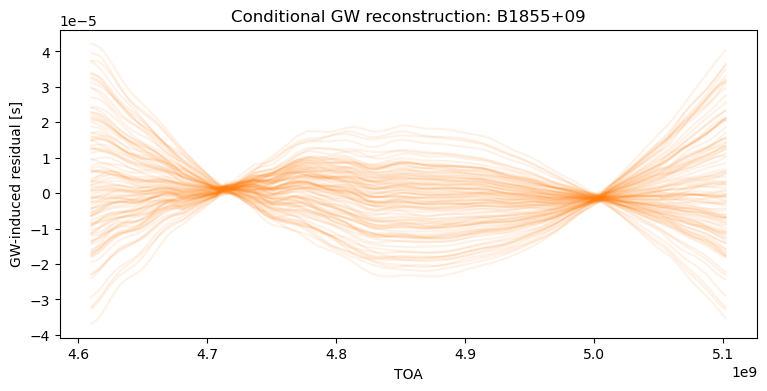

In [9]:
# per-pulsar GW basis, keyed like the coefficient dictionary
gw_bases = dict(zip(gbl.globalgp.index.keys(), gbl.globalgp.Fs))

psr0 = psrs[0]
gw_key = next(k for k in coefficients if k.startswith(psr0.name))

plt.figure(figsize=(9, 4))
for ii in range(100):
    key, coefficients = gbl.sample_conditional(key, params)
    recon = np.asarray(gw_bases[gw_key]) @ coefficients[gw_key]
    plt.plot(psr0.toas, recon, c='C1', alpha=0.1)
plt.xlabel('TOA')
plt.ylabel('GW-induced residual [s]')
plt.title(f'Conditional GW reconstruction: {psr0.name}')
plt.show()

## Use cases

Conditional sampling underlies several analysis techniques:

- **Outlier identification** -- identify timing outliers by examining residuals
  after removing the conditional GP realization
  ([Wang & Taylor 2021](https://arxiv.org/abs/2112.05698)).
- **Signal reconstruction and posterior predictive tests** -- reconstruct
  stochastic signals and perform posterior predictive checks
  ([NANOGrav 2024](https://arxiv.org/abs/2407.20510)).

## Limitations

Conditional sampling does not currently support models with **deterministic
delays** (e.g. a `makedelay` component). A `PulsarLikelihood` that includes one
will raise `NotImplementedError` from `conditional` / `sample_conditional`.

*Workaround:* build a separate likelihood without the deterministic delay for
conditional sampling.

## See also

- `PulsarLikelihood.conditional` / `PulsarLikelihood.sample_conditional`
- `GlobalLikelihood.sample_conditional`
- `discovery.prior.sample_uniform`
- The data-model guide for the GP mathematical framework.